# Welcome to the interactive Galaxy IPython Notebook.

You can access your data via the dataset number. Using a Python kernel, you can access dataset number 42 with ``handle = open(get(42), 'r')``.
To save data, write your data to a file, and then call ``put('filename.txt')``. The dataset will then be available in your galaxy history.
<br>When using a non-Python kernel, ``get`` and ``put`` are available as command-line tools, which can be accessed using system calls in R, Julia, and Ruby. For example, to read dataset number 42 into R, you can write ```handle <- file(system('get -i 42', intern = TRUE))```.
To save data in R, write the data to a file and then call ``system('put -p filename.txt')``.
Notebooks can be saved to Galaxy by clicking the large green button at the top right of the IPython interface.<br>
More help and informations can be found on the project [website](https://github.com/bgruening/docker-jupyter-notebook).

In [26]:
import os
import pandas as pd

for root, dirs, files in os.walk("galaxy_inputs"):
    print(root)
    for f in files:
        print("   ", f)

galaxy_inputs
    galaxy_inputs.json
    galaxy_inputs_raw.json
galaxy_inputs/humann
    HUMAnN_HSMA33KQ:Pathways.tabular
    HUMAnN_HSM6XRRV:Families.tabular
    HUMAnN_HSM5MD6Q:Pathways.tabular
    HUMAnN_HSM7CYYP:Families.tabular
    HUMAnN_HSMA33KQ:Families.tabular
    HUMAnN_HSM7CYYP:Pathways.tabular
    HUMAnN_HSM6XRRV:Pathways.tabular
    HUMAnN_HSM5MD6Q:Families.tabular


In [27]:
import pandas as pd
import glob
import os

typedata = "Families"
pathway_files = glob.glob(f"galaxy_inputs/humann/*{typedata}.tabular")

merged = None

for f in pathway_files:
    sample = os.path.basename(f)
    sample = sample.replace("HUMAnN_", "")
    sample = sample.replace(f":{typedata}.tabular", "")

    df = pd.read_csv(f, sep="\t")
    df.columns = [typedata, sample]

    df = df[~df[typedata].isin(["UNMAPPED", "UNINTEGRATED"])]
    df = df[~df[typedata].str.contains(r"\|", regex=True)]

    if merged is None:
        merged = df
    else:
        merged = merged.merge(df, on=typedata, how="outer")

merged = merged.fillna(0)
print(f"Total de {typedata}", merged.shape)
merged.head()

Total de Families (4399, 5)


,Families,HSM6XRRV,HSM7CYYP,HSMA33KQ,HSM5MD6Q
0,UniRef50_A0A010Z9N5,0.0,0.000000,21.861771,0.000000
1,UniRef50_A0A011QUE4,0.0,0.000000,0.000000,10.881088
2,UniRef50_A0A011QXR4: Phosphate import ATP-bind...,0.0,10.460318,0.000000,0.000000
3,UniRef50_A0A011VRY2,0.0,0.000000,11.627907,0.000000
4,UniRef50_A0A015PCH9: Signal peptidase I domain...,0.0,21.361687,0.000000,0.000000


In [20]:
# ! pip install matplotlib scikit-learn

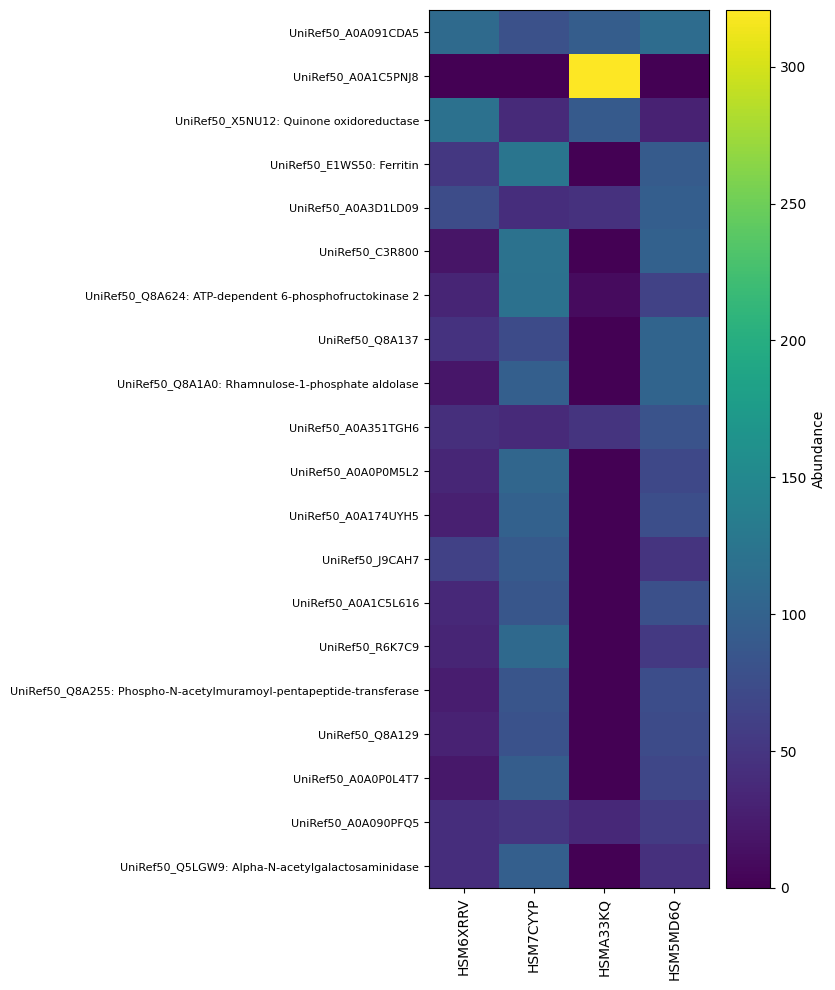

In [28]:
import matplotlib.pyplot as plt
import numpy as np

heat = merged.set_index(typedata)

top20 = heat.mean(axis=1).sort_values(
    ascending=False
).head(20).index

heat_top = heat.loc[top20]

plt.figure(figsize=(8,10))

plt.imshow(
    heat_top.values,
    aspect="auto"
)

plt.colorbar(label="Abundance")

plt.yticks(
    range(len(heat_top.index)),
    heat_top.index,
    fontsize=8
)

plt.xticks(
    range(len(heat_top.columns)),
    heat_top.columns,
    rotation=90
)

plt.tight_layout()

# plt.savefig(
#     "outputs/heatmap_top20_pathways.png",
#     dpi=300
# )

plt.show()

In [22]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# matriz: filas = pathways, columnas = muestras
heat = merged.set_index(typedata)

# opcional: remover filas con suma 0
heat = heat.loc[heat.sum(axis=1) > 0]

# transponer: filas = muestras, columnas = pathways
X = heat.T

In [23]:
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    coords,
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df

,PC1,PC2
HSM6XRRV,-19.607725,-61.650544
HSM7CYYP,51.988628,13.626632
HSMA33KQ,-66.978603,35.232368
HSM5MD6Q,34.597700,12.791544


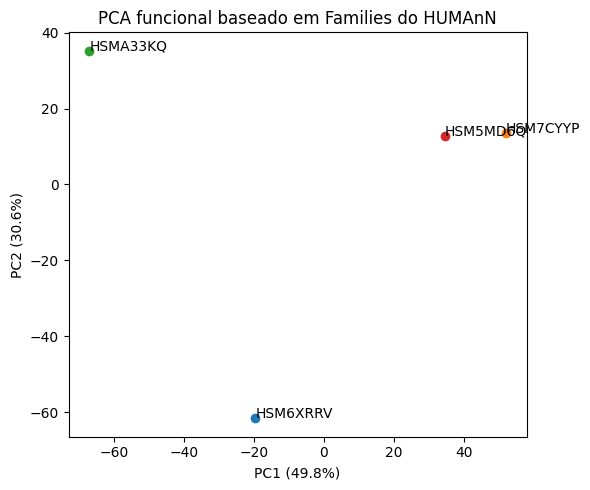

In [24]:
plt.figure(figsize=(6,5))

for sample in pca_df.index:
    plt.scatter(
        pca_df.loc[sample, "PC1"],
        pca_df.loc[sample, "PC2"]
    )
    plt.text(
        pca_df.loc[sample, "PC1"],
        pca_df.loc[sample, "PC2"],
        sample
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title(f"PCA funcional baseado em {typedata} do HUMAnN")
plt.tight_layout()
# plt.savefig("outputs/pca_pathways.png", dpi=300)
plt.show()

# put("outputs/pca_pathways.png")

In [25]:
put("outputs/ipython_galaxy_notebook.ipynb")

/opt/conda/lib/python3.12/site-packages/galaxy_ie_helpers/__init__.py:24: SyntaxWarning: invalid escape sequence '\.'
  cmd_grep = ['grep', '^0\.0\.0\.0']


ValueError: invalid file outputs/ipython_galaxy_notebook.ipynb